# Dataset Prediction Visualiser

Loads the dataset defined by `CONFIG_PATH`, filters to a chosen subset, and
visualises predictions for `N_SAMPLES` randomly-drawn (or sequential) videos.

**Steps:**
1. Set config / checkpoint paths and sampling parameters in **Cell 1**.
2. Run all cells.  
3. Re-run **Cell 6** to draw a fresh random sample without reloading the model.

## 1 — Configuration

In [ ]:
import os

# ── Edit these ────────────────────────────────────────────────────────────────
CONFIG_PATH     = 'configs/experiments/trifuse_tridet.yaml'
CHECKPOINT_PATH = 'runs/exp/trifuse_tridet/model_best.pth.tar'

# Which split to draw samples from:  'train' | 'val' | 'test'
SUBSET          = 'val'

# How many videos to visualise
N_SAMPLES       = 5

# Set to an integer to make sampling reproducible; None = different each run
RANDOM_SEED     = None

# If True, sample randomly; if False, take the first N_SAMPLES from the subset
RANDOM_SAMPLE   = True

# Visualisation options
DISPLAY_THRESHOLD = 0.20   # minimum score for a predicted segment to be shown
MAX_SHOW          = 15     # cap on number of predicted segments per video
# ─────────────────────────────────────────────────────────────────────────────

## 2 — Imports & path setup

In [128]:
import sys, yaml, json, random
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Make sure the adapted_actionformer package is importable
_src_dir = os.path.dirname(os.path.abspath(''))
if _src_dir not in sys.path:
    sys.path.insert(0, _src_dir)

from libs.modeling.meta_arch import HatefulContentLocalizer

%matplotlib inline
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## 3 — Load config, model, annotations

In [129]:
def load_config(path: str) -> dict:
    """Load YAML and resolve relative feature/annotation paths."""
    config_dir = os.path.dirname(os.path.abspath(path))
    with open(path) as f:
        cfg = yaml.safe_load(f)
    ds = cfg['dataset']
    for key in ('video_feat_dir', 'audio_feat_dir', 'text_feat_dir', 'annotation_file'):
        if key in ds and not os.path.isabs(ds[key]):
            ds[key] = os.path.normpath(os.path.join(config_dir, ds[key]))
    return cfg


cfg    = load_config(CONFIG_PATH)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Annotation file: {cfg["dataset"]["annotation_file"]}')

# Load model
model = HatefulContentLocalizer(cfg).to(device)
ckpt  = torch.load(CHECKPOINT_PATH, map_location='cpu')
model.load_state_dict(ckpt.get('state_dict', ckpt))
model.eval()
print(f'Loaded checkpoint: {CHECKPOINT_PATH}')

# Load annotations
with open(cfg['dataset']['annotation_file']) as f:
    annotations = json.load(f)['database']
print(f'Annotation DB size: {len(annotations)} videos')

Device: cuda
Annotation file: c:\Users\Georgiy\Documents\coursework\hateful content localisation\data\hateclipseg\dataset\hateclipseg.json
Loaded checkpoint: runs/exp/trifuse_tridet/model_best.pth.tar
Annotation DB size: 431 videos


## 4 — Build the video list for the chosen subset

Uses the same `build_dataloader` path as `train.py` so that split logic
(`use_json_split`, stratified splits) and missing-feature filtering are
applied consistently.

In [130]:
def _get_build_dataloader(cfg):
    name = cfg.get('dataset', {}).get('name', 'hatemm')
    if name == 'hateclipseg':
        from libs.datasets.hateclipseg import build_dataloader
    elif name == 'multihateclip':
        from libs.datasets.multihateclip import build_dataloader
    else:
        from libs.datasets.hatemm import build_dataloader
    return build_dataloader


build_dataloader = _get_build_dataloader(cfg)
# is_training=False: no weighted sampler, deterministic ordering
loader     = build_dataloader(cfg, subset=SUBSET, is_training=False)
subset_ids = list(loader.dataset.video_ids)  # only IDs with all feature files present

print(f'Dataset name : {cfg["dataset"].get("name", "hatemm")}')
print(f'Subset       : {SUBSET}')
print(f'Videos with features available: {len(subset_ids)}')

if not subset_ids:
    raise ValueError(f'No videos with feature files found for subset "{SUBSET}".')

[HateClipSegDataset] Stratified internal split: 345 train / 86 val (val_ratio=0.2, seed=42)
[HateClipSegDataset] Loaded 321 videos for subset='train' (24 skipped — features not yet available)
Dataset name : hateclipseg
Subset       : train
Videos with features available: 321


## 5 — Helper functions

In [131]:
def load_video_features(cfg: dict, video_id: str) -> dict:
    """
    Load and pad/crop the three modality feature files for `video_id`.
    Returns a batch dict ready for the model (batch size = 1).
    """
    ds  = cfg['dataset']
    msl = ds.get('max_seq_len', 512)

    def _load(feat_dir: str) -> torch.Tensor:
        path = os.path.join(feat_dir, f'{video_id}.pt')
        t    = torch.load(path, map_location='cpu').float()
        if t.ndim == 1:
            t = t.unsqueeze(0)
        return t  # (T, D)

    video_feat = _load(ds['video_feat_dir'])
    audio_feat = _load(ds['audio_feat_dir'])
    text_feat  = _load(ds['text_feat_dir'])

    T = video_feat.shape[0]

    def _align(feat: torch.Tensor, target_len: int) -> torch.Tensor:
        L = feat.shape[0]
        if L < target_len:
            pad = torch.zeros(target_len - L, feat.shape[1])
            feat = torch.cat([feat, pad], dim=0)
        return feat[:target_len]

    audio_feat = _align(audio_feat, T)
    text_feat  = _align(text_feat,  T)

    valid_T = min(T, msl)
    mask    = torch.zeros(msl)
    mask[:valid_T] = 1.0

    def _pad_to(feat: torch.Tensor) -> torch.Tensor:
        t2 = torch.zeros(msl, feat.shape[1])
        t2[:valid_T] = feat[:valid_T]
        return t2

    batch = {
        'video_id'   : [video_id],
        'video_feat' : _pad_to(video_feat).unsqueeze(0),
        'audio_feat' : _pad_to(audio_feat).unsqueeze(0),
        'text_feat'  : _pad_to(text_feat).unsqueeze(0),
        'mask'       : mask.unsqueeze(0),
        'duration'   : [annotations[video_id]['duration'] if video_id in annotations else float(T)],
    }
    return batch, valid_T


@torch.no_grad()
def run_inference_with_internals(model, batch, device):
    """
    Mirrors HatefulContentLocalizer.forward() in eval mode but also returns
    the raw per-FPN-level cls scores and point positions for visualisation.
    """
    from libs.utils.nms import soft_nms
    from torch.nn import functional as F

    text  = batch['text_feat'].to(device)
    audio = batch['audio_feat'].to(device)
    video = batch['video_feat'].to(device)
    mask  = batch['mask'].to(device)

    fused       = model.preprocessor(text, audio, video)
    x           = fused.permute(0, 2, 1)
    mask_bcT    = mask.unsqueeze(1).bool()
    feats, masks         = model.backbone(x, mask_bcT)
    fpn_feats, fpn_masks = model.neck(feats, masks)
    points      = model.point_generator(fpn_feats)
    raw_cls     = model.cls_head(fpn_feats, fpn_masks)
    raw_off     = model.reg_head(fpn_feats, fpn_masks)
    out_cls     = [c.permute(0, 2, 1) for c in raw_cls]
    out_off     = [o.permute(0, 2, 1) for o in raw_off]
    masks_2d    = [m.squeeze(1) for m in fpn_masks]

    if model.use_trident_head:
        raw_lb = model.start_head(fpn_feats, fpn_masks)
        raw_rb = model.end_head(fpn_feats, fpn_masks)
    else:
        raw_lb = raw_rb = None

    fps = cfg['dataset'].get('feature_fps', 1.0)
    level_scores, level_times, level_offsets = [], [], []
    segs_all, scores_all = [], []

    for lvl, (cls_i, off_i, pts_i, msk_i) in enumerate(
        zip(out_cls, out_off, points, masks_2d)
    ):
        score     = (cls_i[0].sigmoid() * msk_i[0].unsqueeze(-1)).squeeze(-1).cpu()
        pts_cpu   = pts_i.cpu()
        t_centres = pts_cpu[:, 0].numpy() / fps

        if model.use_trident_head:
            nb      = model.num_bins
            sb      = raw_lb[lvl][0]
            eb      = raw_rb[lvl][0]
            x_pad   = F.pad(sb, (nb, 0), mode='constant', value=0).unsqueeze(-1)
            sz      = list(x_pad.size()); sz[-1] = nb + 1; sz[-2] -= nb
            st      = list(x_pad.stride()); st[-2] = st[-1]
            start_nb = x_pad.as_strided(size=sz, stride=st)
            x_pad   = F.pad(eb, (0, nb), mode='constant', value=0).unsqueeze(-1)
            end_nb  = x_pad.as_strided(size=sz, stride=st)
            off_decoded = model.decode_offset(off_i[0], start_nb, end_nb)
            off_cpu     = off_decoded[0].cpu()
        else:
            off_cpu = off_i[0].cpu()

        seg_l   = (pts_cpu[:, 0] - off_cpu[:, 0] * pts_cpu[:, 3]).numpy() / fps
        seg_r   = (pts_cpu[:, 0] + off_cpu[:, 1] * pts_cpu[:, 3]).numpy() / fps
        decoded = np.stack([seg_l, seg_r], axis=1)

        level_scores.append(score.numpy())
        level_times.append(t_centres)
        level_offsets.append(decoded)

        keep = score > model.score_threshold
        if keep.sum() > 0:
            segs_all.append(torch.tensor(decoded[keep.numpy()]) * fps)
            scores_all.append(score[keep])

    if segs_all:
        segs_cat, scores_cat = torch.cat(segs_all), torch.cat(scores_all)
        segs_nms, scores_nms = soft_nms(
            segs_cat, scores_cat,
            sigma=model.nms_sigma,
            min_score=model.score_threshold,
            max_num=model.max_detections,
        )
        segs_sec = (segs_nms / fps).clamp(min=0.0, max=float(batch['duration'][0]))
    else:
        segs_sec   = torch.zeros((0, 2))
        scores_nms = torch.zeros((0,))

    results = [{
        'video_id': batch['video_id'][0],
        'segments': segs_sec,
        'scores'  : scores_nms,
        'labels'  : torch.zeros(segs_sec.shape[0], dtype=torch.long),
    }]
    return results, level_scores, level_times, level_offsets


def make_dense_score_curve(level_scores, level_times, duration, fps=1.0):
    n_bins = int(np.ceil(duration)) + 1
    dense  = np.zeros(n_bins)
    for scores, times in zip(level_scores, level_times):
        for t, s in zip(times, scores):
            idx = int(round(t))
            if 0 <= idx < n_bins:
                dense[idx] = max(dense[idx], float(s))
    return np.arange(n_bins), dense


def make_boundary_histograms(level_scores, level_offsets, level_times, duration, n_bins=50):
    bin_edges   = np.linspace(0, duration, n_bins + 1)
    onset_hist  = np.zeros(n_bins)
    offset_hist = np.zeros(n_bins)
    for scores, offsets, times in zip(level_scores, level_offsets, level_times):
        for i, (s, (t_start, t_end)) in enumerate(zip(scores, offsets)):
            if s < 1e-4:
                continue
            idx_s = np.searchsorted(bin_edges, t_start, side='right') - 1
            idx_e = np.searchsorted(bin_edges, t_end,   side='right') - 1
            if 0 <= idx_s < n_bins:
                onset_hist[idx_s]  += float(s)
            if 0 <= idx_e < n_bins:
                offset_hist[idx_e] += float(s)
    bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    return bin_centres, onset_hist, offset_hist


def visualise(video_id, res, level_scores, level_times, level_offsets,
              annotations, duration, display_threshold=0.10, max_show=10):
    fps    = cfg['dataset'].get('feature_fps', 1.0)
    t_axis, dense = make_dense_score_curve(level_scores, level_times, duration, fps)
    bin_c, onset_h, offset_h = make_boundary_histograms(
        level_scores, level_offsets, level_times, duration
    )

    gt_segs = []
    if video_id in annotations:
        for ann in annotations[video_id].get('annotations', []):
            gt_segs.append(ann['segment'])

    pred_segs   = res['segments'].numpy()
    pred_scores = res['scores'].numpy()
    keep_mask   = pred_scores >= display_threshold
    pred_segs   = pred_segs[keep_mask][:max_show]
    pred_scores = pred_scores[keep_mask][:max_show]

    fig, axes = plt.subplots(
        3, 1, figsize=(14, 8),
        gridspec_kw={'height_ratios': [3, 3, 2]},
        sharex=False,
    )
    fig.suptitle(f'Temporal predictions  —  {video_id}', fontsize=13, fontweight='bold')

    ax1 = axes[0]
    ax1.bar(t_axis, dense, width=0.8, color='#d62728', alpha=0.85,
            label='Action score (max over FPN levels)')
    ax1.set_xlim(0, duration)
    ax1.set_ylim(0, max(dense.max() * 1.15, 0.05))
    ax1.set_ylabel('Score', fontsize=10)
    ax1.set_title('Action scores at each time step', fontsize=10)
    ax1.legend(fontsize=8, loc='upper right')
    for s, e in gt_segs:
        ax1.axvspan(s, e, alpha=0.15, color='green')
        ax1.axvline(s, color='green', linewidth=1.0, linestyle='--', alpha=0.6)
        ax1.axvline(e, color='green', linewidth=1.0, linestyle='--', alpha=0.6)

    ax2 = axes[1]
    width = bin_c[1] - bin_c[0] if len(bin_c) > 1 else 1.0
    ax2.bar(bin_c, onset_h,  width=width * 0.45, align='center',
            color='#1f77b4', alpha=0.85, label='Predicted Onset')
    ax2.bar(bin_c + width * 0.45, offset_h, width=width * 0.45, align='center',
            color='#ff7f0e', alpha=0.85, label='Predicted Offset')
    ax2.set_xlim(0, duration)
    ax2.set_ylabel('Weighted count', fontsize=10)
    ax2.set_title('Onset / offset distribution (score-weighted)', fontsize=10)
    ax2.legend(fontsize=8, loc='upper right')
    for s, e in gt_segs:
        ax2.axvline(s, color='green', linewidth=1.2, linestyle='--', alpha=0.7)
        ax2.axvline(e, color='green', linewidth=1.2, linestyle='--', alpha=0.7)

    ax3 = axes[2]
    ax3.set_xlim(0, duration)
    ax3.set_ylim(0, 1)
    ax3.set_yticks([])
    ax3.set_xlabel('Time (seconds)', fontsize=10)
    ax3.set_title('Temporal segments', fontsize=10)
    for s, e in gt_segs:
        ax3.add_patch(mpatches.Rectangle(
            (s, 0.55), e - s, 0.35,
            linewidth=1.5, edgecolor='green', facecolor='#2ca02c', alpha=0.55,
        ))
        ax3.text((s + e) / 2, 0.73, f'GT\n{s:.0f}\u2013{e:.0f}s',
                 ha='center', va='center', fontsize=7, color='darkgreen', fontweight='bold')
    norm = Normalize(vmin=display_threshold, vmax=1.0)
    cmap = plt.cm.Reds
    for s, e, sc in zip(pred_segs[:, 0], pred_segs[:, 1], pred_scores):
        colour = cmap(0.4 + 0.6 * norm(sc))
        ax3.add_patch(mpatches.Rectangle(
            (s, 0.10), e - s, 0.35,
            linewidth=1.0, edgecolor='darkred', facecolor=colour, alpha=0.75,
        ))
        ax3.text((s + e) / 2, 0.28, f'{sc:.2f}\n{s:.0f}\u2013{e:.0f}s',
                 ha='center', va='center', fontsize=7, color='darkred')
    legend_patches = [
        mpatches.Patch(color='#2ca02c', alpha=0.6, label='Ground truth'),
        mpatches.Patch(color='#d62728', alpha=0.6, label='Prediction (score shown)'),
    ]
    ax3.legend(handles=legend_patches, fontsize=8, loc='upper right')

    plt.tight_layout()
    plt.show()

## 6 — Sample videos & run visualisation

Re-run this cell to draw a fresh random sample (with a new seed if `RANDOM_SEED=None`).

Visualising 5 videos from subset "train":
  bit_FK4MGsKanAnE
  bit_2ZR4SYsWDs7V
  bit_d39rrxdDEC5D
  bit_QR9jyRugyFak
  bit_0dcMcI6hYjhw

[1/5] bit_FK4MGsKanAnE ... duration=185.0s  feat_frames=185  preds=17


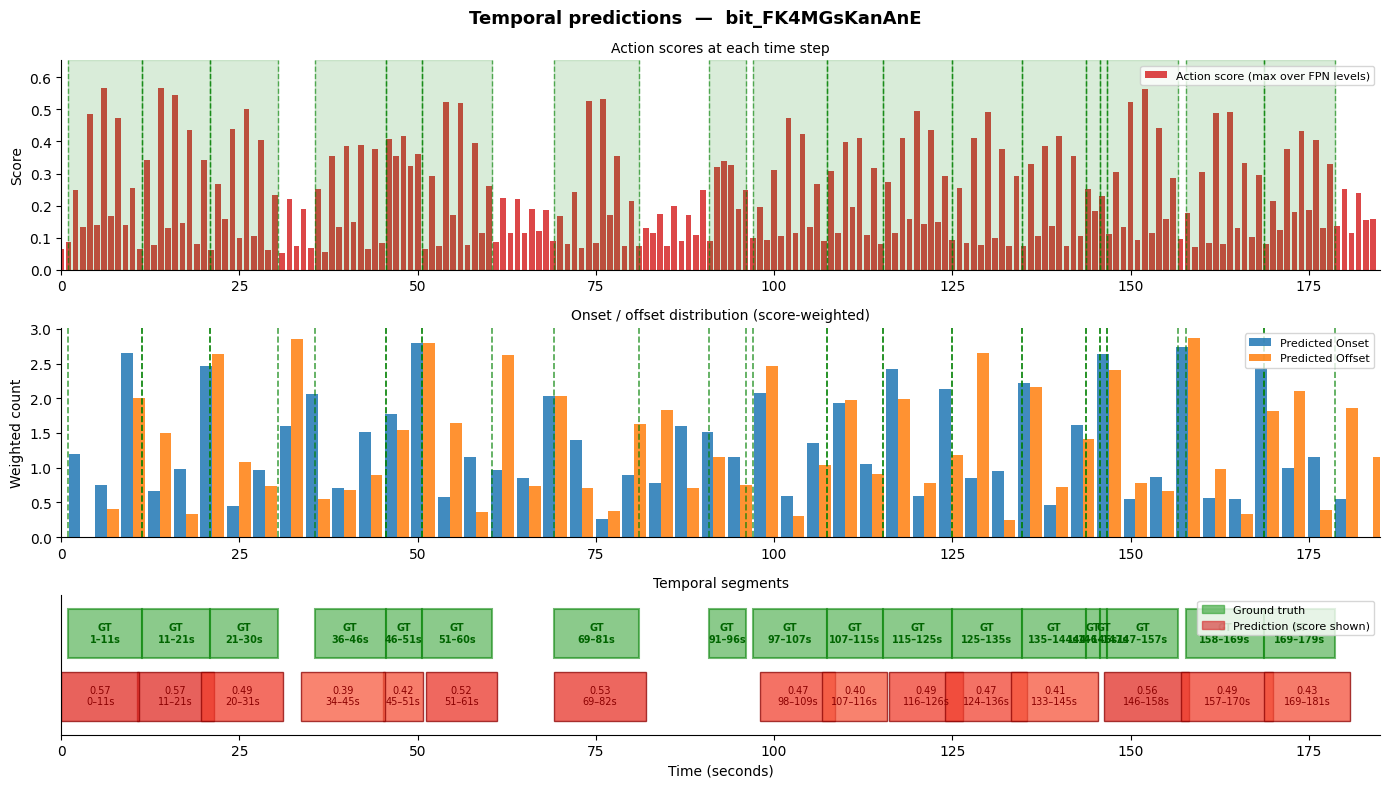

[2/5] bit_2ZR4SYsWDs7V ... duration=236.0s  feat_frames=236  preds=21


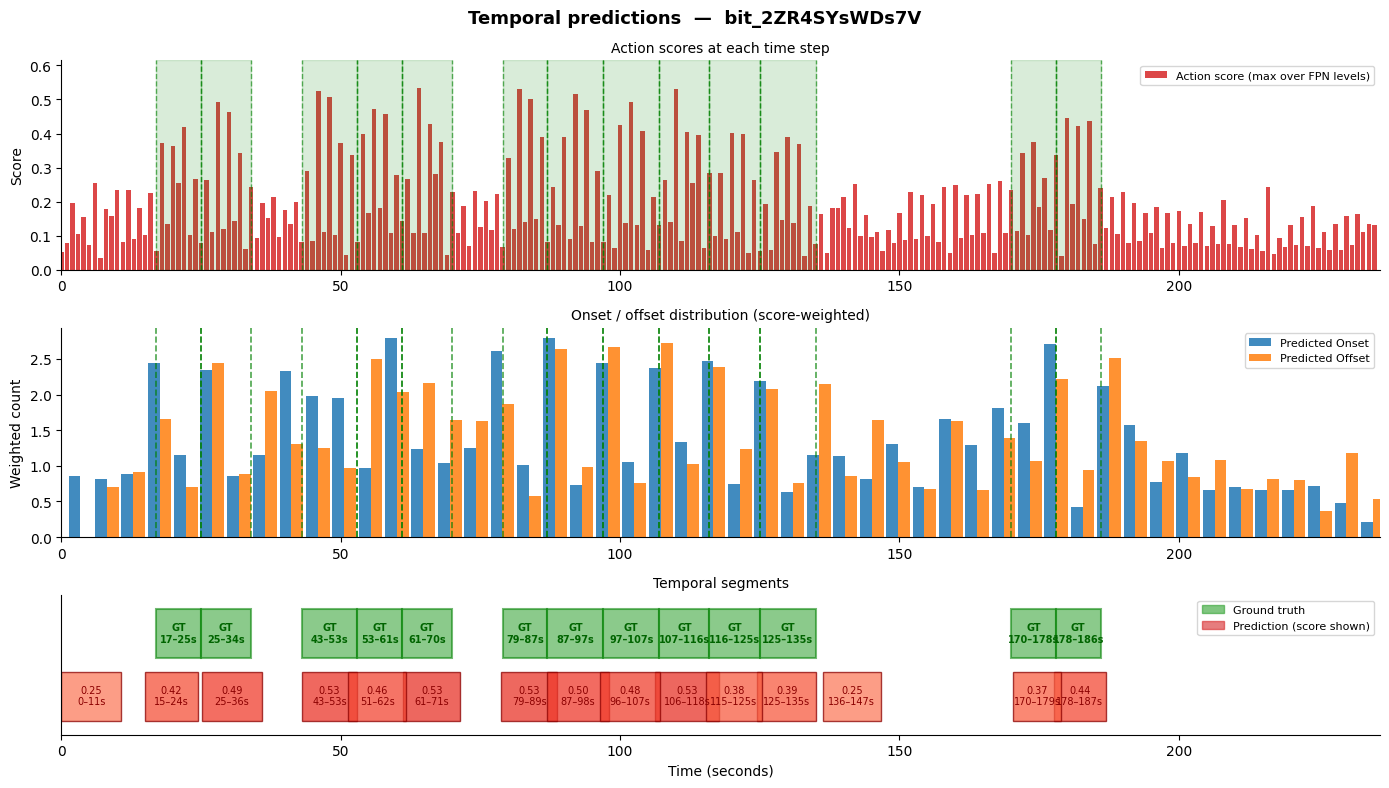

[3/5] bit_d39rrxdDEC5D ... duration=185.0s  feat_frames=185  preds=4


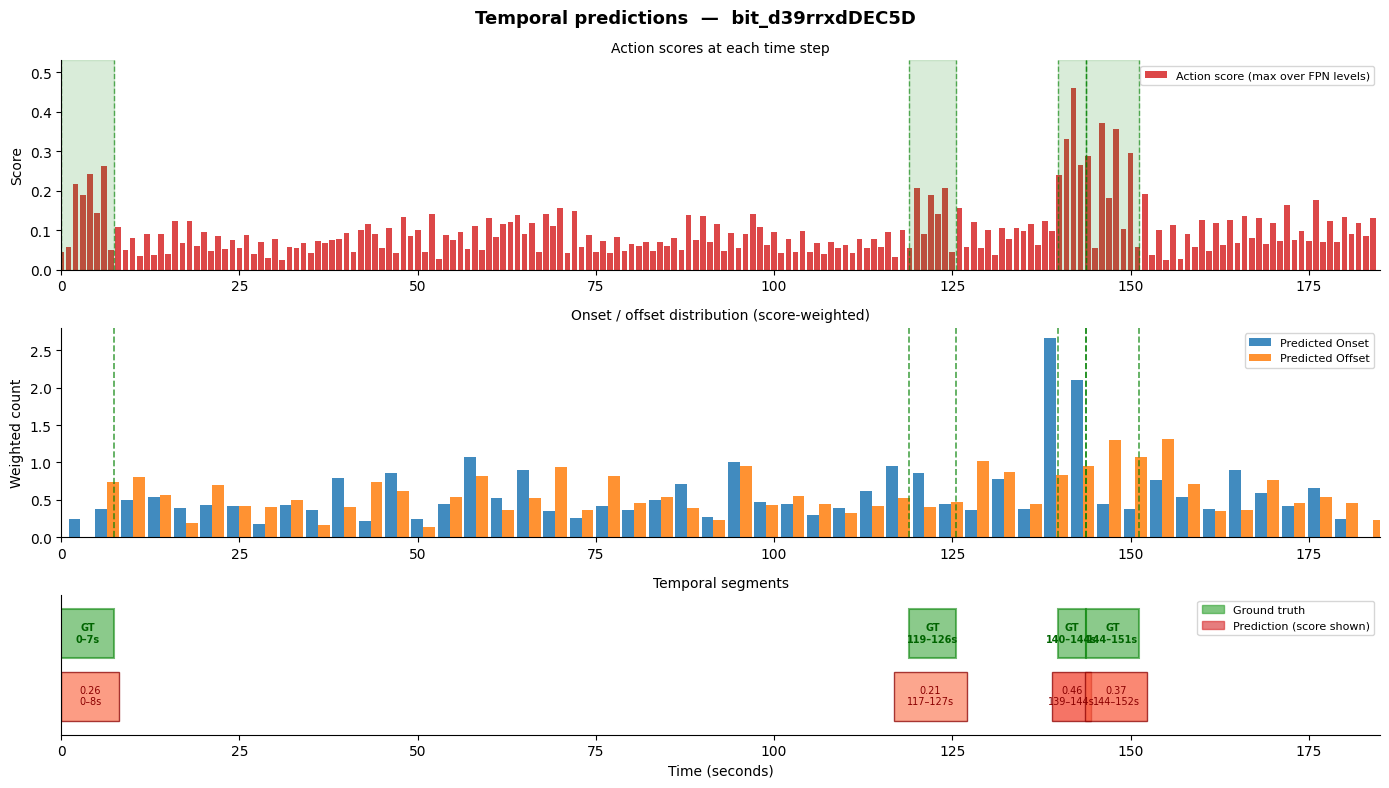

[4/5] bit_QR9jyRugyFak ... duration=295.0s  feat_frames=295  preds=5


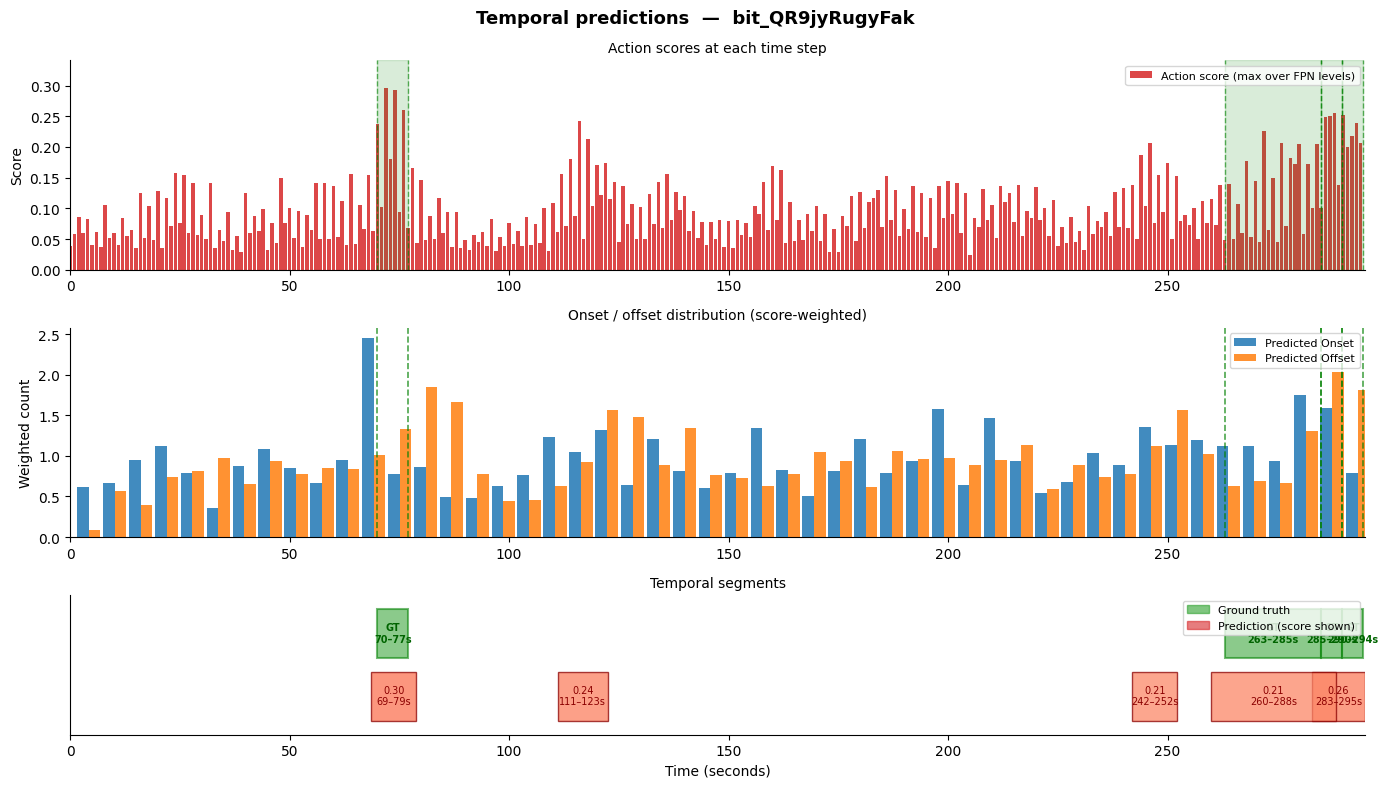

[5/5] bit_0dcMcI6hYjhw ... duration=223.0s  feat_frames=223  preds=26


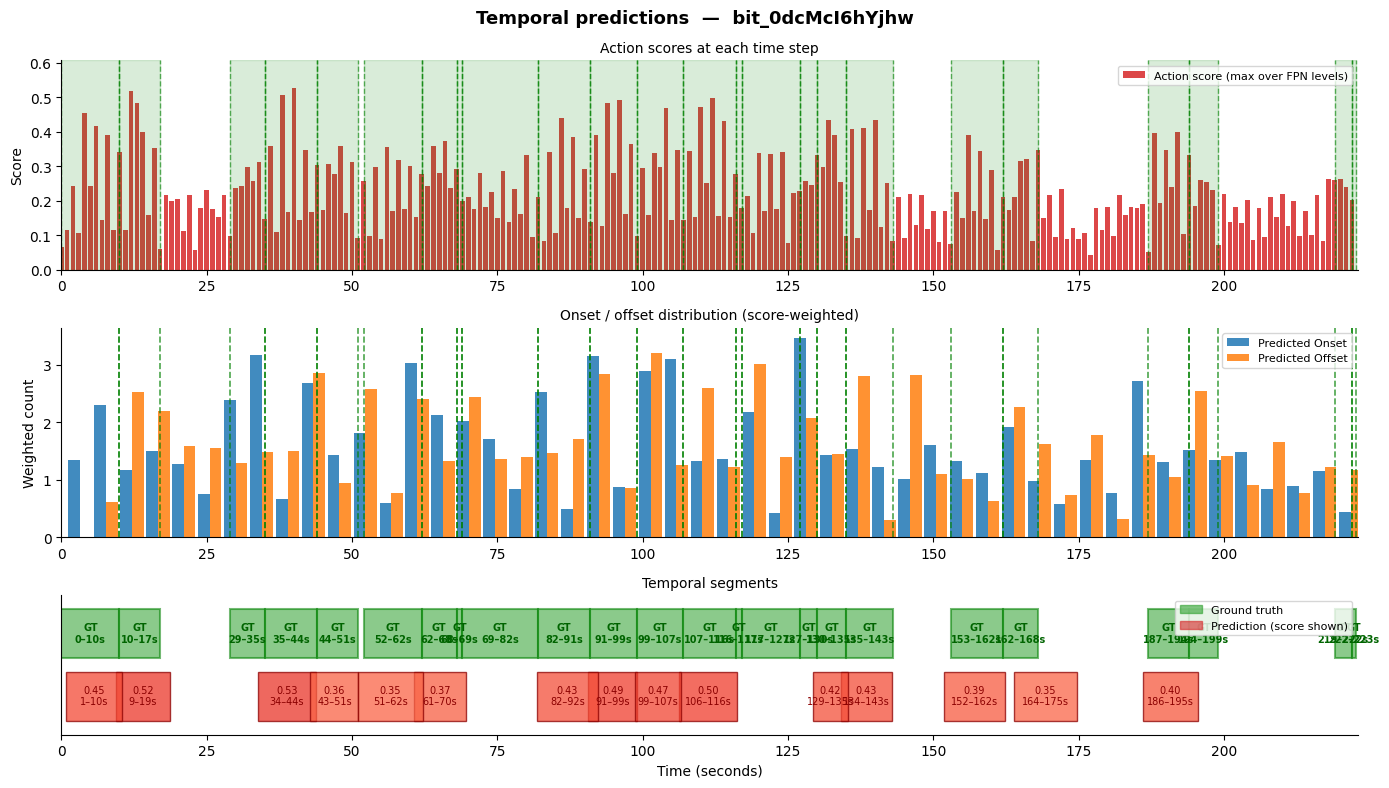

In [132]:
rng = random.Random(RANDOM_SEED)

if RANDOM_SAMPLE:
    sample_ids = rng.sample(subset_ids, min(N_SAMPLES, len(subset_ids)))
else:
    sample_ids = subset_ids[:N_SAMPLES]

print(f'Visualising {len(sample_ids)} videos from subset "{SUBSET}":')
for vid in sample_ids:
    print(f'  {vid}')
print()

for idx, video_id in enumerate(sample_ids):
    print(f'[{idx + 1}/{len(sample_ids)}] {video_id}', end=' ... ')
    try:
        batch, valid_T = load_video_features(cfg, video_id)
        duration       = batch['duration'][0]
        results, level_scores, level_times, level_offsets = run_inference_with_internals(
            model, batch, device
        )
        res = results[0]
        n_pred = (res['scores'].numpy() >= DISPLAY_THRESHOLD).sum()
        print(f'duration={duration:.1f}s  feat_frames={valid_T}  preds={n_pred}')
        visualise(
            video_id, res, level_scores, level_times, level_offsets,
            annotations, duration,
            display_threshold=DISPLAY_THRESHOLD,
            max_show=MAX_SHOW,
        )
    except FileNotFoundError as exc:
        print(f'SKIPPED — feature file missing: {exc}')
    except Exception as exc:
        print(f'ERROR — {exc}')
        raise